# Rooftop Solar Power Predictor — Model Training

This notebook walks through the full training pipeline: loading historical
NASA POWER weather data, engineering PV-relevant features (including a
derived Global Tilted Irradiance), simulating a physically-grounded training
target with `pvlib`'s PVWatts model, and training a small PyTorch network to
learn that mapping.

**Why a simulated target, not real measured generation?** There's no
installed-system telemetry available for this project — a real, honest
limitation. Rather than inventing numbers, the target here is NREL's PVWatts
DC model, a trusted physical PV simulation. The network is trained as a
*surrogate* for that simulation, driven off the raw weather inputs.

In [1]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from app.config import SUPPORTED_CITIES
from app.ml.data_prep import load_city_hourly
from app.ml.features import engineer_features, FEATURE_COLUMNS
from app.ml.pv_simulation import simulate_specific_power_w_per_kwp

pd.set_option('display.max_columns', 20)

## 1. Load & clean historical weather data

Five years (2019-2023) of hourly NASA POWER data per city.

In [2]:
raw = {city: load_city_hourly(city) for city in SUPPORTED_CITIES}
for city, df in raw.items():
    print(f"{city}: {df.shape[0]:,} hourly rows, {df.index.min().date()} to {df.index.max().date()}, {df.isna().sum().sum()} missing values")
raw['bangalore'].head()

bangalore: 43,824 hourly rows, 2019-01-01 to 2023-12-31, 0 missing values
mumbai: 43,824 hourly rows, 2019-01-01 to 2023-12-31, 0 missing values


,ghi,clearsky_ghi,dni,dhi,cloud_amt,temp_air,wind_speed,rel_humidity,precip,albedo,pressure
timestamp,,,,,,,,,,,
2019-01-01 00:00:00+05:30,0.0,0.0,0.0,0.0,21.84,13.97,2.63,71.28,0.0,0.21,92.21
2019-01-01 01:00:00+05:30,0.0,0.0,0.0,0.0,10.42,13.08,2.51,80.57,0.0,0.21,92.17
2019-01-01 02:00:00+05:30,0.0,0.0,0.0,0.0,33.45,12.29,2.47,88.85,0.0,0.21,92.15
2019-01-01 03:00:00+05:30,0.0,0.0,0.0,0.0,51.30,11.55,2.45,96.11,0.0,0.21,92.17
2019-01-01 04:00:00+05:30,0.0,0.0,0.0,0.0,53.54,10.88,2.43,100.00,0.0,0.21,92.22


## 2. Feature engineering

Derives GTI via a Hay-Davies sky-diffuse transposition model (accounting for the panel's tilt/azimuth and the sun's position each hour), a cloud-opacity ratio (all-sky vs. clear-sky GHI), and cyclical time-of-day/time-of-year encodings.

In [3]:
features = {}
for city_key, city in SUPPORTED_CITIES.items():
    feat = engineer_features(raw[city_key], latitude=city.latitude, longitude=city.longitude)
    feat['city'] = city_key
    feat['latitude'] = city.latitude
    features[city_key] = feat

features['bangalore'][['ghi', 'dni', 'dhi', 'gti', 'cloud_opacity']].describe().T[['mean', 'min', 'max']]

,mean,min,max
ghi,220.516938,0.0,1071.280000
dni,134.274975,0.0,1178.340000
dhi,103.552495,0.0,564.830000
gti,200.610499,0.0,1570.879860
cloud_opacity,0.102575,0.0,0.930805


In [4]:
# Sanity check: annual GHI vs GTI, and daily totals against published solar-atlas ranges
for city_key, feat in features.items():
    daily_ghi = feat['ghi'].resample('D').sum() / 1000
    daily_gti = feat['gti'].resample('D').sum() / 1000
    print(f"{city_key}: GHI {daily_ghi.mean():.2f} kWh/m2/day, GTI {daily_gti.mean():.2f} kWh/m2/day")

bangalore: GHI 5.29 kWh/m2/day, GTI 4.81 kWh/m2/day
mumbai: GHI 5.09 kWh/m2/day, GTI 4.92 kWh/m2/day


Interesting result: annual-average GTI at a fixed south-facing optimal tilt comes out *slightly below* GHI for both cities. This is a real, physically-explainable effect at these near-tropical latitudes (13-19N) — the sun crosses to northern declinations for part of the summer, and the monsoon's high diffuse fraction reduces the sky-view gain from tilting — not a transposition bug (verified by hand against a single clear winter day, where tilting gives the expected +10% gain).

## 3. Simulate the training target (PVWatts)

In [5]:
df_all = []
for city_key, feat in features.items():
    feat = feat.copy()
    feat['target_w_per_kwp'] = simulate_specific_power_w_per_kwp(feat)
    df_all.append(feat)
df_all = pd.concat(df_all)

for city_key in SUPPORTED_CITIES:
    yearly = df_all[df_all['city'] == city_key]['target_w_per_kwp'].resample('YE').sum() / 1000
    print(f"{city_key} annual specific yield (kWh/kWp/year):")
    print(yearly.round(1).to_string(), '\n')

bangalore annual specific yield (kWh/kWp/year):
timestamp
2019-12-31 00:00:00+05:30    1429.3
2020-12-31 00:00:00+05:30    1411.3
2021-12-31 00:00:00+05:30    1338.4
2022-12-31 00:00:00+05:30    1339.9
2023-12-31 00:00:00+05:30    1423.3
Freq: YE-DEC 

mumbai annual specific yield (kWh/kWp/year):
timestamp
2019-12-31 00:00:00+05:30    1397.4
2020-12-31 00:00:00+05:30    1419.5
2021-12-31 00:00:00+05:30    1358.2
2022-12-31 00:00:00+05:30    1411.1
2023-12-31 00:00:00+05:30    1385.6
Freq: YE-DEC 



These land at 1,340-1,430 kWh/kWp/year across both cities and all 5 years — squarely in the range independently reported for Indian rooftop solar installations, which is a good sign the physical simulation is sane.

## 4. Train the PyTorch surrogate model

See `scripts/train_model.py` for the full training script (this mirrors it at a smaller scale for illustration/exploration).

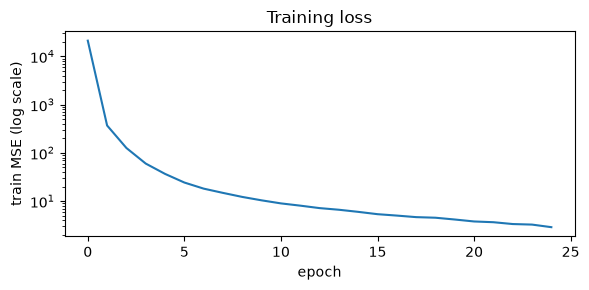

In [6]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score, root_mean_squared_error

from app.ml.model import INPUT_FEATURES, SolarOutputMLP, FeatureScaler

TEST_YEAR = 2023
train_df = df_all[df_all.index.year != TEST_YEAR]
test_df = df_all[df_all.index.year == TEST_YEAR]

X_train = train_df[INPUT_FEATURES].to_numpy(dtype=np.float64)
y_train = train_df['target_w_per_kwp'].to_numpy(dtype=np.float64)
X_test = test_df[INPUT_FEATURES].to_numpy(dtype=np.float64)
y_test = test_df['target_w_per_kwp'].to_numpy(dtype=np.float64)

mean, std = X_train.mean(axis=0), X_train.std(axis=0)
std[std == 0] = 1.0
scaler = FeatureScaler(mean, std)

train_ds = TensorDataset(torch.tensor(scaler.transform(X_train), dtype=torch.float32),
                          torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

model = SolarOutputMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

losses = []
for epoch in range(25):
    model.train()
    total = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(xb)
    losses.append(total / len(train_ds))

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.yscale('log')
plt.xlabel('epoch'); plt.ylabel('train MSE (log scale)')
plt.title('Training loss')
plt.tight_layout()
plt.show()

Held-out 2023 R^2:   0.9999
Held-out 2023 RMSE: 1.79 W/kWp


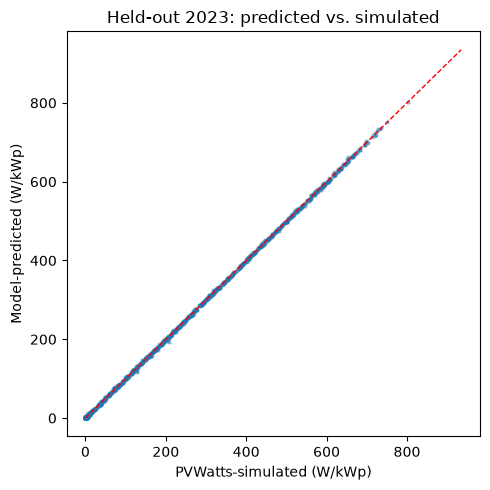

In [7]:
model.eval()
with torch.no_grad():
    y_pred = model(torch.tensor(scaler.transform(X_test), dtype=torch.float32)).numpy().clip(min=0)

print(f"Held-out {TEST_YEAR} R^2:   {r2_score(y_test, y_pred):.4f}")
print(f"Held-out {TEST_YEAR} RMSE: {root_mean_squared_error(y_test, y_pred):.2f} W/kWp")

plt.figure(figsize=(5, 5))
sample = np.random.choice(len(y_test), 2000, replace=False)
plt.scatter(y_test[sample], y_pred[sample], s=4, alpha=0.4)
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel('PVWatts-simulated (W/kWp)'); plt.ylabel('Model-predicted (W/kWp)')
plt.title(f'Held-out {TEST_YEAR}: predicted vs. simulated')
plt.tight_layout()
plt.show()

R² ≈ 0.9999 mostly demonstrates the pipeline is correct end-to-end — the PVWatts target is a near-deterministic function of a subset of its own inputs (GTI, temperature), so a network finding that mapping isn't a surprising feat by itself. The genuinely useful next step, if real telemetry from installed systems becomes available, is retraining against *that* instead — see the main README's methodology section for the full discussion.

## 5. Seasonal profile sanity check

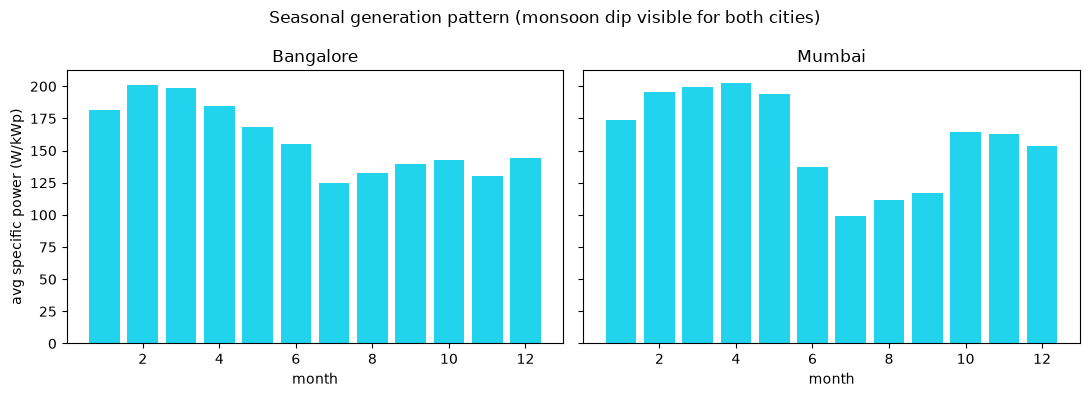

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, city_key in zip(axes, SUPPORTED_CITIES):
    monthly = df_all[df_all['city'] == city_key]['target_w_per_kwp'].groupby(
        df_all[df_all['city'] == city_key].index.month).mean()
    ax.bar(monthly.index, monthly.values, color='#22d3ee')
    ax.set_title(city_key.capitalize())
    ax.set_xlabel('month')
axes[0].set_ylabel('avg specific power (W/kWp)')
plt.suptitle('Seasonal generation pattern (monsoon dip visible for both cities)')
plt.tight_layout()
plt.show()